# Частотный взгляд на нейросети: гармонический анализ, F -принцип и динамика обучения 
## Практическая часть
### Цели: 
- Проверить на синтетических примерах наличие F-принципа 
- Установить практически насколько сильно признаки Фурье ускоряют обучение высоких частот
- Исследовать влияние ширины сети и шага обучения на спектральные кривые 

### F-принцип на синтетических примерах

#### Установка необходимых библиотек:

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random

def set_seed(seed=42):
    random.seed(seed)                # стандартный python
    np.random.seed(seed)             # numpy
    torch.manual_seed(seed)          # CPU
    torch.cuda.manual_seed(seed)     # GPU
    torch.cuda.manual_seed_all(seed) # все GPU

set_seed(42)

torch.use_deterministic_algorithms(True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Целевые функции

In [2]:
#сумма синусов с заданными частотами и амплитудами
def generate_1d_function(n_samples=1024, freqs=[1, 3, 5], amplitudes=None):
    x = np.linspace(0, 2*np.pi, n_samples)
    
    if amplitudes is None:
        amplitudes = np.ones(len(freqs))
    
    y = np.zeros_like(x)
    for a, f in zip(amplitudes, freqs):
        y += a * np.sin(f * x)
    
    return x, y

#### MLP сеть

In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim=1, hidden=256, depth=6, activation='tanh'):
        super().__init__()
        
        act = nn.Tanh() if activation == 'tanh' else nn.ReLU()
        
        layers = [nn.Linear(in_dim, hidden), act]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), act]
        layers += [nn.Linear(hidden, 1)]
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

#### Фурье-коэффициенты

In [4]:
# 1D FFT
def compute_fft_1d(signal):
    fft = np.fft.fft(signal)
    return fft

#### Визуализация

##### Ошибки по частотам

In [5]:
def plot_spectral_dynamics(spectral_errors, true_freqs):
    spectral_errors = np.array(spectral_errors)

    # делим частоты на низкие и высокие
    sorted_freqs = sorted(true_freqs)
    mid = len(sorted_freqs) // 2
    
    low_freqs = sorted_freqs[:mid]
    high_freqs = sorted_freqs[mid:]
    
    plt.figure(figsize=(10, 6))
    
    for k in sorted_freqs:
        plt.plot(
            spectral_errors[:, k],
            linewidth=2.5,
            label=f"k={k} (true)"
        )
    
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("E_k(t)")
    plt.title("Spectral Error Dynamics (highlighted true frequencies)")
    
    plt.legend()
    plt.tight_layout()
    plt.show()

##### Итог обучения

In [6]:
def plot_fit(x, y, model):
    with torch.no_grad():
        pred = model(torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device))
        pred = pred.cpu().numpy()
    
    plt.plot(x, y, label="True")
    plt.plot(x, pred, '--', label="MLP")
    plt.legend()
    plt.show()

#### Обучение и измерение спектра

In [7]:
def train_with_spectral_tracking(x, y, epochs, lr=1e-2, activation='tanh', seed=42):

    set_seed(seed)
    
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)
    
    model = MLP(activation=activation).to(device)
    loss_fn = nn.MSELoss()
    
    # истинный спектр
    true_fft = compute_fft_1d(y)
    
    spectral_errors = []
    
    for epoch in range(epochs):
        
        # прямой проход 
        pred = model(x_tensor)
        loss = loss_fn(pred, y_tensor)
        
        # вычисление градиентов 
        loss.backward()
        
        # явный шаг градиентного спуска
        with torch.no_grad(): # отключаем автоматическое обновление параметров
            for param in model.parameters():
                param -= lr * param.grad
        
        # обнуление градиентовв, чтобы избежать накопления
        model.zero_grad()
        
        # спектральный анализ
        with torch.no_grad():
            pred_np = pred.cpu().numpy().flatten()
            pred_fft = compute_fft_1d(pred_np)
            
            Ek = np.abs(true_fft - pred_fft) ** 2
            spectral_errors.append(Ek)

        # каждые 10000 итераций визуализируем текущую аппроксимацию
        if epoch % 1000 == 0:
            plot_fit(x, y, model)
            print(f"Epoch {epoch}, Loss {loss.item():.6f}")
    
    plot_fit(x, y, model)
    print(f"Epoch {epoch}, Loss {loss.item():.6f}")
    
    return model, np.array(spectral_errors), true_fft, loss.item()

#### Запуск эксперимента

In [8]:
x, y = generate_1d_function(
    freqs=[3, 6, 9, 12, 15, 18, 21, 24, 27, 30],
)

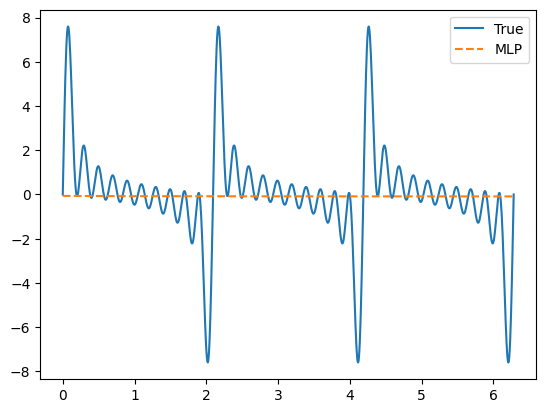

Epoch 0, Loss 5.013363


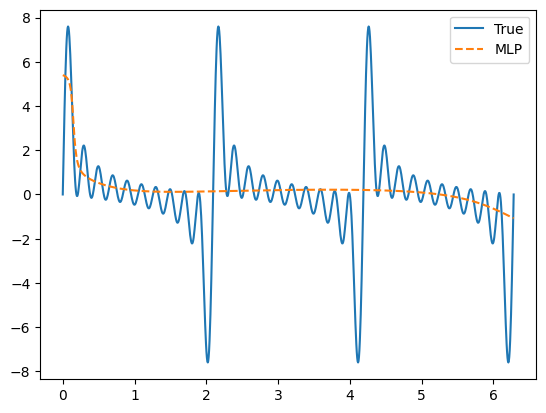

Epoch 1000, Loss 4.052842


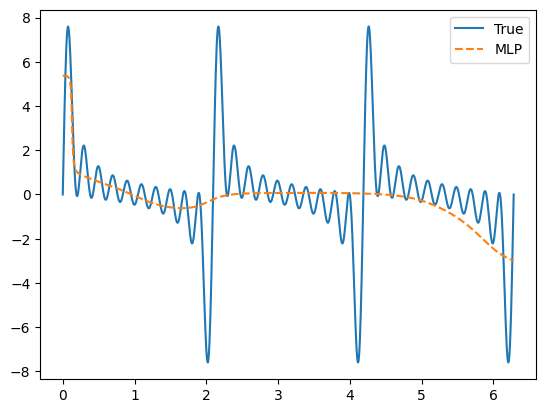

Epoch 2000, Loss 3.884634


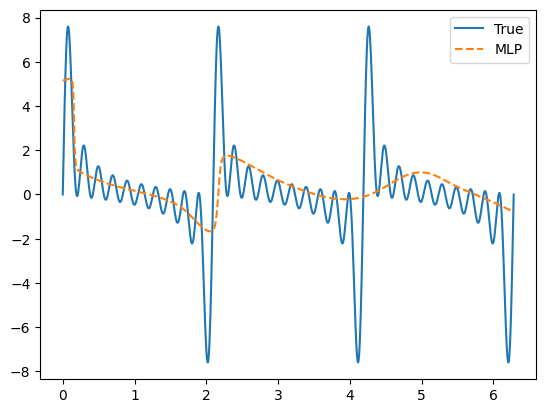

Epoch 3000, Loss 3.934626


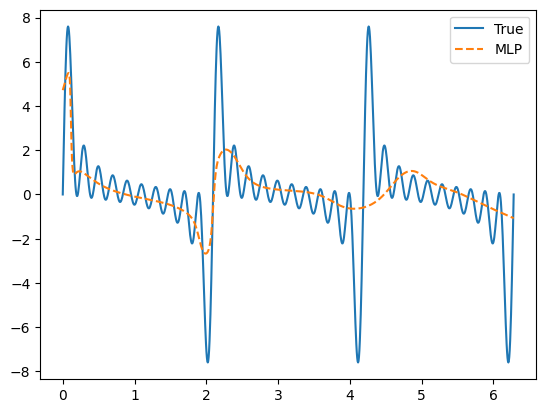

Epoch 4000, Loss 3.761444


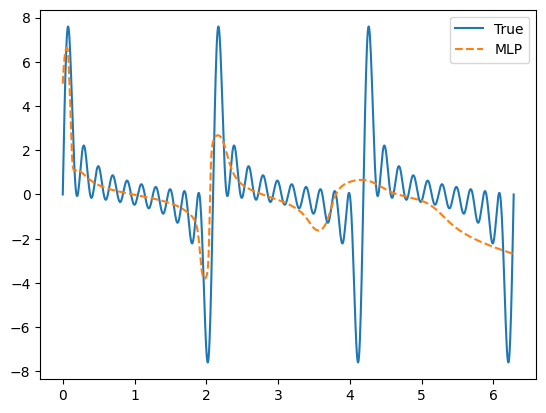

Epoch 5000, Loss 2.740910


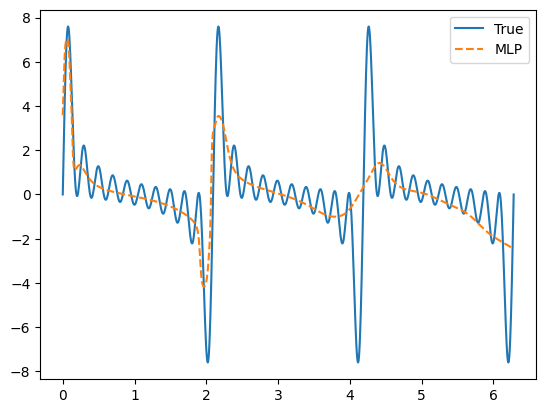

Epoch 6000, Loss 2.588863


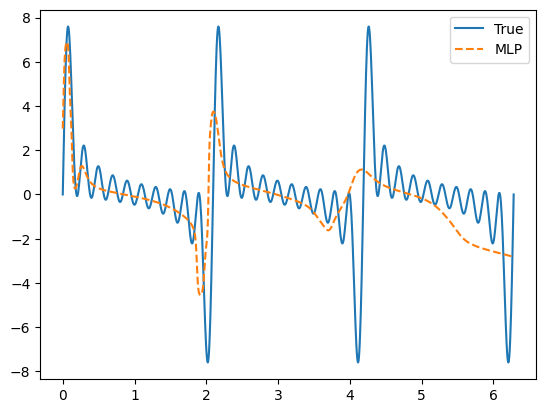

Epoch 7000, Loss 3.544919


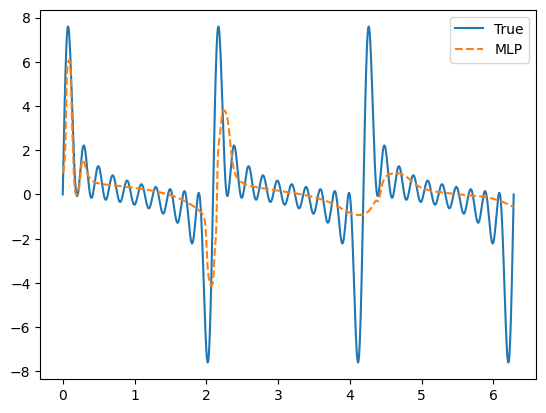

Epoch 8000, Loss 3.647204


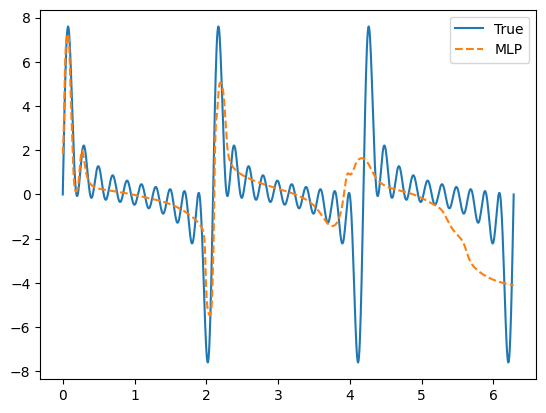

Epoch 9000, Loss 2.327147


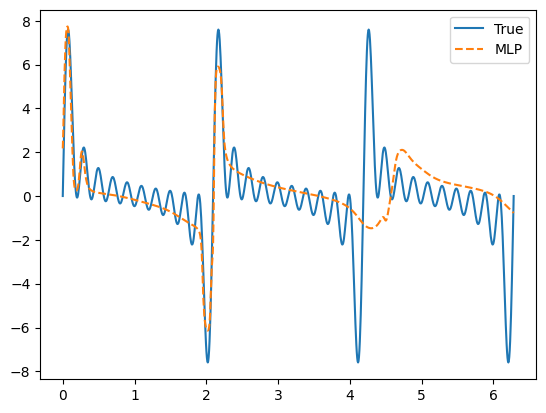

Epoch 9999, Loss 2.186523


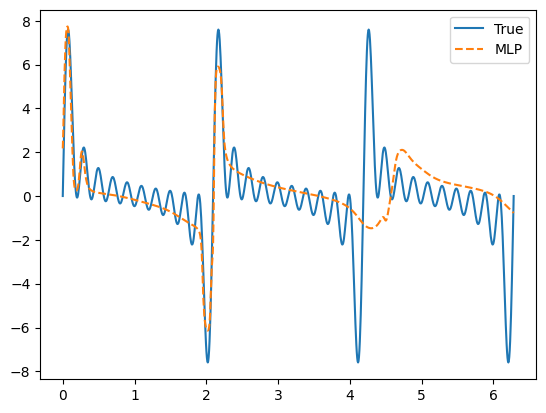

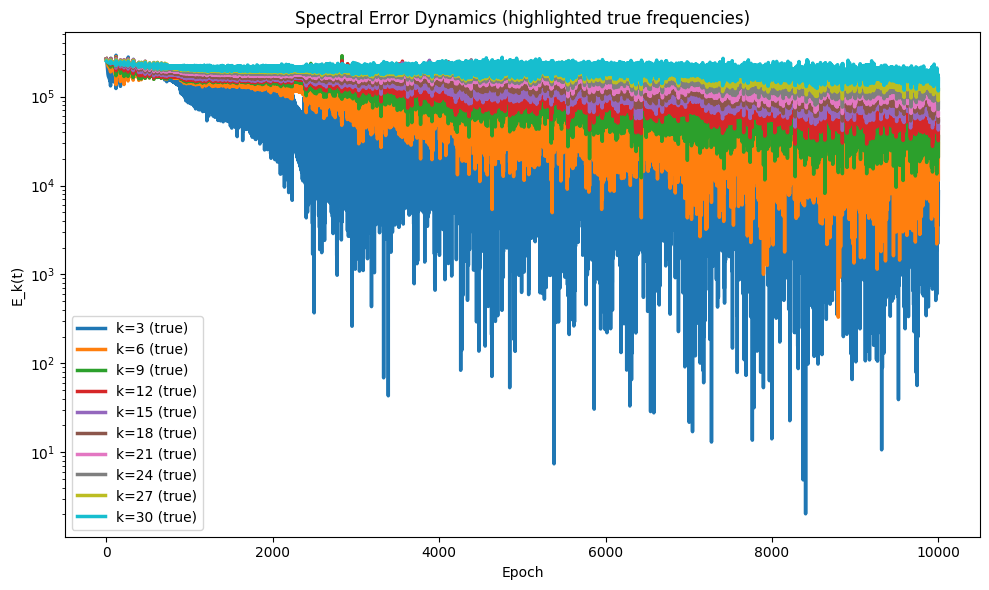

In [9]:
model, spectral_errors, true_fft, loss_baseline = train_with_spectral_tracking(
    x, y, epochs=10000, lr = 5e-2, activation='tanh'
)

plot_fit(x, y, model)
plot_spectral_dynamics(spectral_errors, true_freqs=[3, 6, 9, 12, 15, 18, 21, 24, 27, 30])

#### Признаки Фурье

Используется отображение


$$\gamma(v)=[a_1\cos(2\pi b_1^Tv), a_1\sin(2\pi b_1^Tv), \dots, a_m\cos(2\pi b_m^Tv), a_m\sin(2\pi b_m^Tv)]$$

Для одномерного входа \(v=x\) векторы \(b_i\) становятся скалярами.


In [10]:
class FourierFeatures(nn.Module):
    def __init__(self, m=64, sigma=10.0, trainable=False, seed=42):
        super().__init__()

        g = torch.Generator()
        g.manual_seed(seed)

        B = torch.randn(m, 1) * sigma
        A = torch.ones(m)

        if trainable:
            self.B = nn.Parameter(B)
            self.A = nn.Parameter(A)
        else:
            self.register_buffer("B", B)
            self.register_buffer("A", A)

        self.out_dim = 2 * m

    def forward(self, x):
        proj = 2 * np.pi * x @ self.B.T
        return torch.cat([
            self.A * torch.cos(proj),
            self.A * torch.sin(proj)
        ], dim=-1)


class MLPFourier(nn.Module):
    def __init__(self, m=64, sigma=10.0,
                 hidden=256, depth=6, activation='tanh'):
        super().__init__()

        self.ff = FourierFeatures(m=m, sigma=sigma, seed=42)

        layers = []
        in_dim = self.ff.out_dim

        act = nn.Tanh if activation == 'tanh' else nn.ReLU

        layers.append(nn.Linear(in_dim, hidden))
        layers.append(act())

        for _ in range(depth - 1):
            layers.append(nn.Linear(hidden, hidden))
            layers.append(act())

        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(self.ff(x))


In [11]:
def train_with_fourier_features(
    x, y, epochs, lr=1e-2,
    activation='tanh',
    m=64,
    sigma=10.0,
    seed=42):

    set_seed(seed)
    flag = False

    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)

    model = MLPFourier(
        m=m,
        sigma=sigma,
        activation=activation
    ).to(device)

    loss_fn = nn.MSELoss()
    true_fft = compute_fft_1d(y)

    spectral_errors = []

    for epoch in range(epochs):

        pred = model(x_tensor)
        loss = loss_fn(pred, y_tensor)

        loss.backward()

        with torch.no_grad():
            for p in model.parameters():
                p -= lr * p.grad

        model.zero_grad()

        with torch.no_grad():
            pred_fft = compute_fft_1d(
                pred.cpu().numpy().flatten()
            )
            spectral_errors.append(
                np.abs(true_fft - pred_fft) ** 2
            )

        if epoch % 1000 == 0:
            plot_fit(x, y, model)
            print(f"Epoch {epoch}, Loss {loss.item():.6f}")

        if not flag and loss.item() - loss_baseline < 1e-6:
            print(f"Achieved loss better than baseline at epoch {epoch} with loss {loss.item():.6f}")
            print(f"Learning with forier features is {10000/epoch} times faster than baseline")
            flag = True 

    return model, np.array(spectral_errors), true_fft


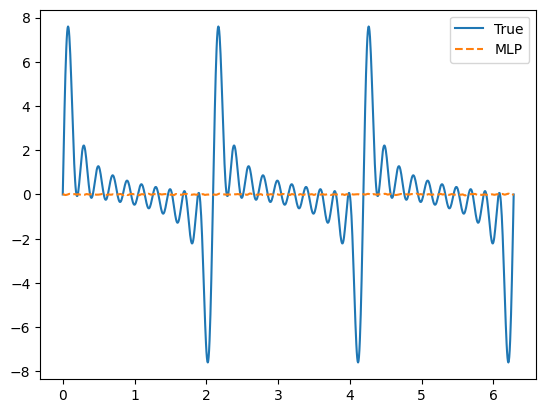

Epoch 0, Loss 4.992114
Achieved loss better than baseline at epoch 48 with loss 2.175047
Learning with forier features is 208.33333333333334 times faster than baseline


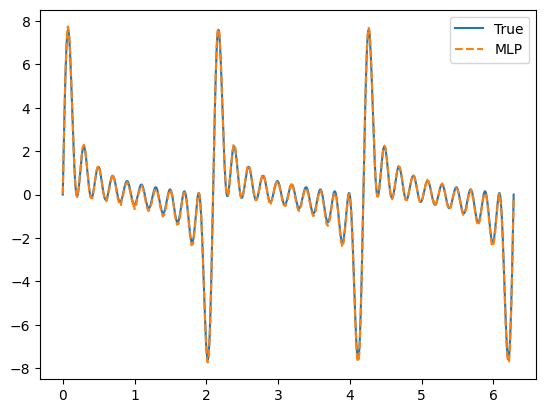

Epoch 1000, Loss 0.008449


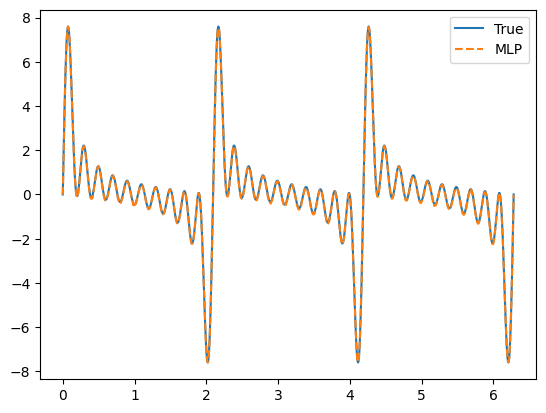

Epoch 2000, Loss 0.001747


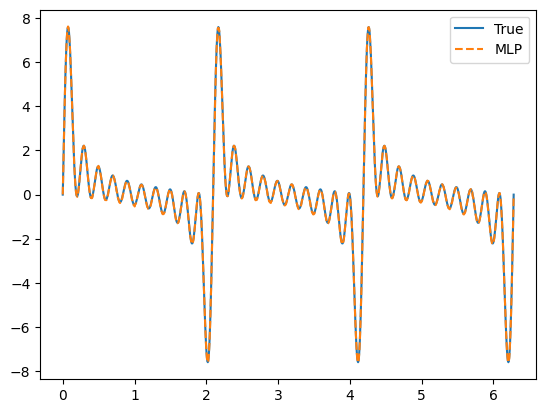

Epoch 3000, Loss 0.000641


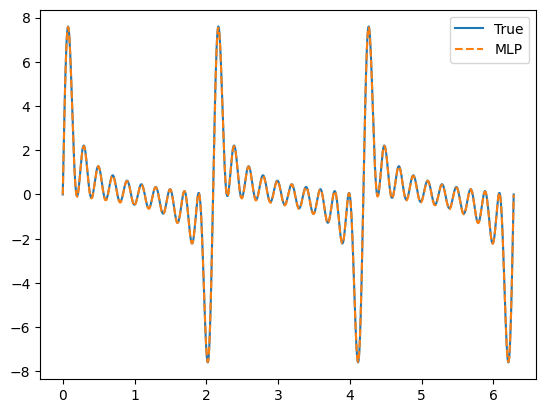

Epoch 4000, Loss 0.000681


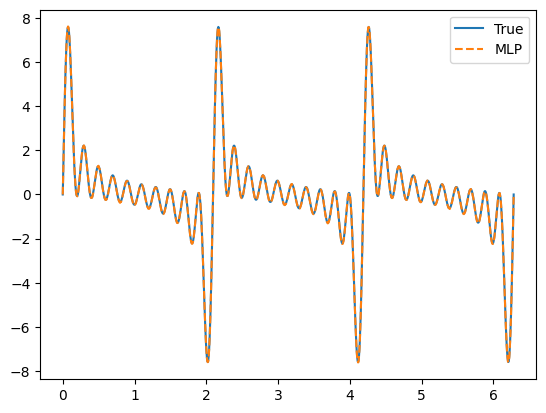

Epoch 5000, Loss 0.000403


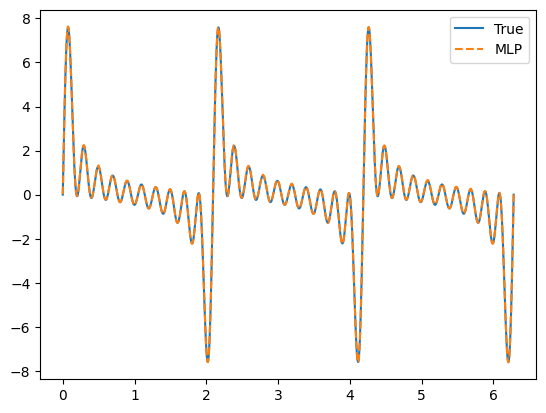

Epoch 6000, Loss 0.000393


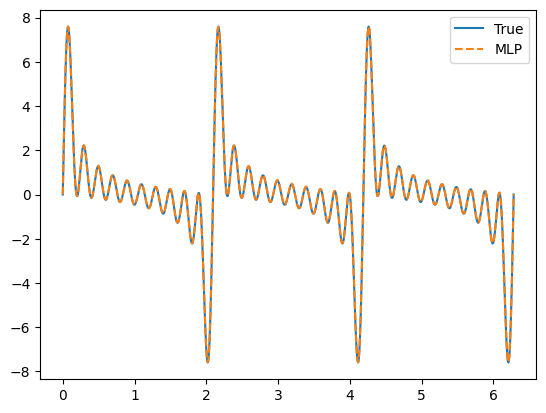

Epoch 7000, Loss 0.000203


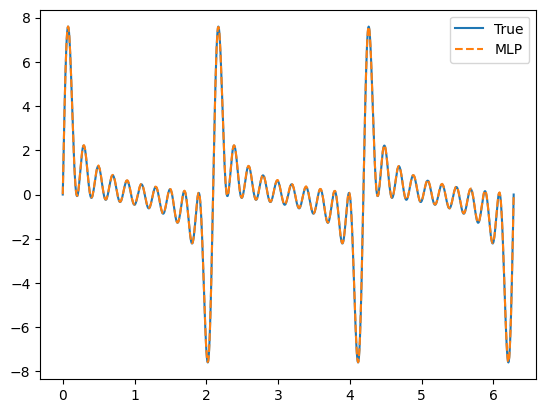

Epoch 8000, Loss 0.000304


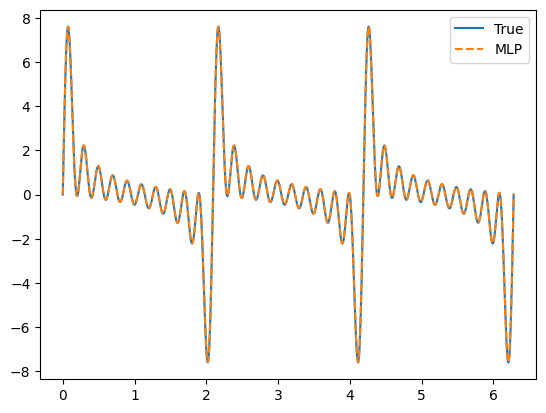

Epoch 9000, Loss 0.000153


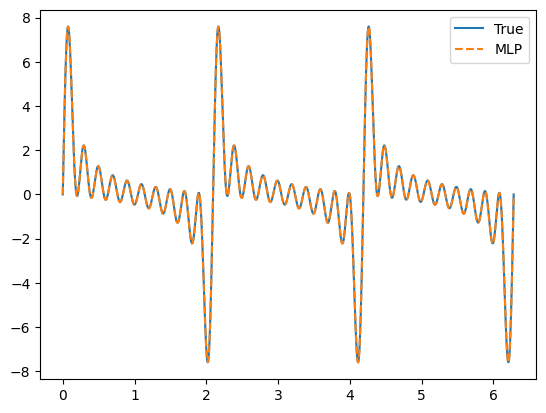

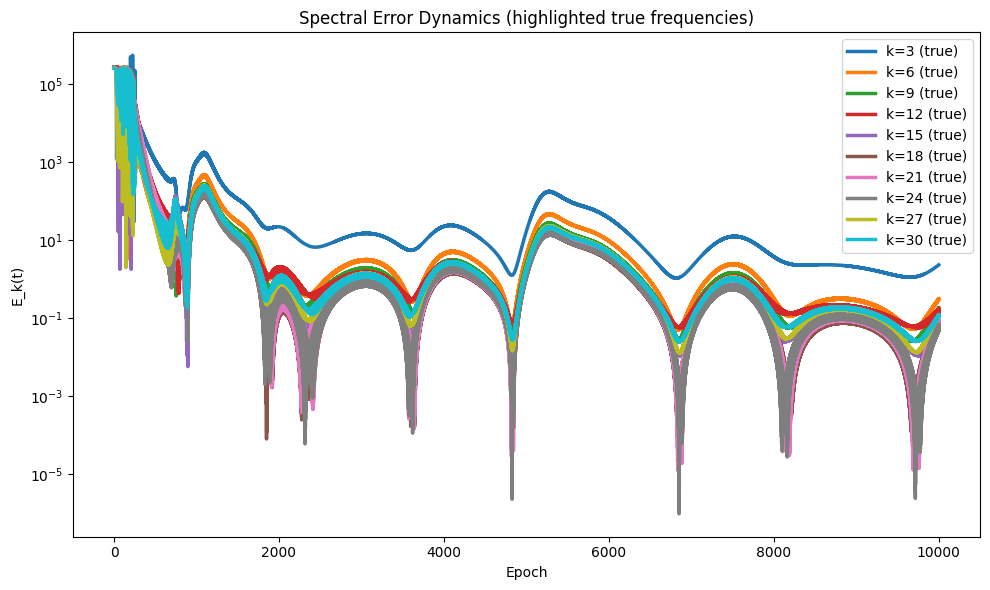

In [12]:
# Эксперимент с Fourier Features

model_ff, spectral_errors_ff, true_fft_ff = train_with_fourier_features(
    x,
    y,
    epochs=10000,
    lr=5e-2,
    activation='tanh',
    m=64,
    sigma=10.0,
    seed=42
)

plot_fit(x, y, model_ff)

plot_spectral_dynamics(
    spectral_errors_ff,
    true_freqs=[3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
)
